+ MERGE SEVERE -> MODERATE // + SMOTE

FEATURES :
Gender, mean_a, mean_B, mean_b, mean_S, mean_R

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Import SMOTE
from imblearn.over_sampling import SMOTE

In [2]:
# =====================================================================
# 1. PERSIAPAN DATA DAN PENGGABUNGAN KELAS
# =====================================================================
EXCEL_PATH = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur.xlsx' 
df = pd.read_excel(EXCEL_PATH)
df = df.dropna(subset=['Anemia_Class', 'Hemoglobin', 'Age', 'Gender'])

df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

print("=== SEBELUM MERGE ===")
print(df['Anemia_Class'].value_counts().sort_index())

df['Anemia_Class'] = df['Anemia_Class'].replace(0.0, 1.0)

print("\n=== SETELAH MERGE SEVERE -> MODERATE/SEVERE ===")
class_names = {3.0: 'Normal (3)', 2.0: 'Mild (2)', 1.0: 'Moderate/Severe (1)'}
print(df['Anemia_Class'].map(class_names).value_counts())

display(df.head())

=== SEBELUM MERGE ===
Anemia_Class
0      3
1     50
2     37
3    121
Name: count, dtype: int64

=== SETELAH MERGE SEVERE -> MODERATE/SEVERE ===
Anemia_Class
Normal (3)             121
Moderate/Severe (1)     53
Mild (2)                37
Name: count, dtype: int64


,Country,Subject_ID,Age,Gender,mean_R,mean_G,mean_B,mean_L,mean_a,mean_b,mean_H,mean_S,mean_V,Hemoglobin,Anemia_Class
0,India,1,29,1,165.681334,82.346387,124.941774,118.559390,166.313710,124.941774,166.367962,130.298180,165.700354,12.2,2
1,India,2,36,0,159.608875,105.623553,119.549809,130.963319,154.832061,119.549809,160.096852,89.443007,160.550162,8.0,1
2,India,3,30,0,142.347389,81.613713,122.984434,108.931662,157.473051,122.984434,164.515150,112.148609,142.947018,10.7,1
3,India,4,39,0,172.217661,131.992063,115.307618,152.968773,149.983883,115.307618,150.293604,71.055925,178.894736,8.3,1
4,India,5,29,0,152.483330,82.745516,123.574996,113.115925,160.959679,123.574996,165.402269,118.849228,152.626490,7.8,1


In [3]:
# =====================================================================
# 2. PEMILIHAN FITUR DAN SPLITTING DATA
# =====================================================================

selected_features = ['Gender', 'mean_a', 'mean_B', 'mean_b', 'mean_S', 'mean_R', 'mean_V']

X = df[selected_features]
y_hb = df['Hemoglobin']
y_class = df['Anemia_Class']

# Splitting data (Gunakan stratify agar proporsi kelas di Train dan Test sama adilnya)
X_train, X_test, y_hb_train, y_hb_test, y_class_train, y_class_test = train_test_split(
    X, y_hb, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [4]:
# =====================================================================
# 3. BALANCING MENGGUNAKAN SMOTE PADA DATA TRAIN
# =====================================================================
print("\n=== PROSES SMOTE (BALANCING) ===")
print("Jumlah data TRAIN sebelum SMOTE:")
print(y_class_train.value_counts())

# Trik SMOTE untuk Regresi: Gabungkan fitur (X) dan target (Hemoglobin) sementara
train_data_combined = pd.concat([X_train, y_hb_train], axis=1)

# Lakukan SMOTE berdasarkan label Anemia_Class
smote = SMOTE(random_state=42)
train_data_resampled, y_class_resampled = smote.fit_resample(train_data_combined, y_class_train)

# Pisahkan kembali fitur (X) dan Hemoglobin (y) setelah diperbanyak
X_train_balanced = train_data_resampled[selected_features].copy()
y_hb_train_balanced = train_data_resampled['Hemoglobin']

# PERBAIKAN PENTING: SMOTE kadang menghasilkan nilai desimal (misal Gender 0.6).
# Kita harus membulatkan nilai Gender kembali ke 0 atau 1.
X_train_balanced['Gender'] = X_train_balanced['Gender'].round().astype(int)

# --- BAGIAN BARU: VISUALISASI HASIL SMOTE ---

print("\nJumlah data TRAIN setelah SMOTE:")
print(y_class_resampled.value_counts())

'''# 1. Menampilkan bentuk DataFrame (Tabel) setelah SMOTE
print("\n[Tabel] 5 Data Teratas setelah SMOTE (Perhatikan Gender yang sudah dibulatkan):")
display(X_train_balanced.head())

# 2. Visualisasi Persebaran Data (Scatter Plot)
# Kita ambil contoh fitur yang paling kuat korelasinya, misal 'mean_a' vs 'Hemoglobin'
class_labels = {3.0: 'Normal (3)', 2.0: 'Mild (2)', 1.0: 'Moderate/Severe (1)'}
y_train_mapped = y_class_train.map(class_labels)
y_resampled_mapped = y_class_resampled.map(class_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafik Kiri: Sebelum SMOTE
sns.scatterplot(ax=axes[0], data=train_data_combined, x='mean_a', y='Hemoglobin', 
                hue=y_train_mapped, palette='Set1', alpha=0.8, edgecolor='k')
axes[0].set_title('Persebaran Data Latih SEBELUM SMOTE')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik Kanan: Sesudah SMOTE
sns.scatterplot(ax=axes[1], data=train_data_resampled, x='mean_a', y='Hemoglobin', 
                hue=y_resampled_mapped, palette='Set1', alpha=0.8, edgecolor='k')
axes[1].set_title('Persebaran Data Latih SESUDAH SMOTE\n(Titik baru ditambahkan pada kelas minoritas)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()'''


=== PROSES SMOTE (BALANCING) ===
Jumlah data TRAIN sebelum SMOTE:
Anemia_Class
3    96
1    42
2    30
Name: count, dtype: int64

Jumlah data TRAIN setelah SMOTE:
Anemia_Class
3    96
1    96
2    96
Name: count, dtype: int64


'# 1. Menampilkan bentuk DataFrame (Tabel) setelah SMOTE\nprint("\n[Tabel] 5 Data Teratas setelah SMOTE (Perhatikan Gender yang sudah dibulatkan):")\ndisplay(X_train_balanced.head())\n\n# 2. Visualisasi Persebaran Data (Scatter Plot)\n# Kita ambil contoh fitur yang paling kuat korelasinya, misal \'mean_a\' vs \'Hemoglobin\'\nclass_labels = {3.0: \'Normal (3)\', 2.0: \'Mild (2)\', 1.0: \'Moderate/Severe (1)\'}\ny_train_mapped = y_class_train.map(class_labels)\ny_resampled_mapped = y_class_resampled.map(class_labels)\n\nfig, axes = plt.subplots(1, 2, figsize=(14, 6))\n\n# Grafik Kiri: Sebelum SMOTE\nsns.scatterplot(ax=axes[0], data=train_data_combined, x=\'mean_a\', y=\'Hemoglobin\', \n                hue=y_train_mapped, palette=\'Set1\', alpha=0.8, edgecolor=\'k\')\naxes[0].set_title(\'Persebaran Data Latih SEBELUM SMOTE\')\naxes[0].grid(True, linestyle=\'--\', alpha=0.6)\n\n# Grafik Kanan: Sesudah SMOTE\nsns.scatterplot(ax=axes[1], data=train_data_resampled, x=\'mean_a\', y=\'Hemoglobi


Jumlah data TRAIN setelah SMOTE:
Anemia_Class
3    96
1    96
2    96
Name: count, dtype: int64


,Gender,mean_a,mean_B,mean_b,mean_S,mean_R,mean_V,Hemoglobin
0,1,163.995628,119.303781,119.303781,110.763673,177.082655,177.139468,13.8
1,0,157.169557,118.229800,118.229800,100.298911,151.873460,152.515563,9.9
2,0,158.479390,119.324908,119.324908,98.739016,166.534222,167.212178,9.2
3,1,161.780038,120.594360,120.594360,109.083034,168.485289,168.549959,11.1
4,1,159.732489,115.264420,115.264420,103.148074,159.438911,161.070303,12.2


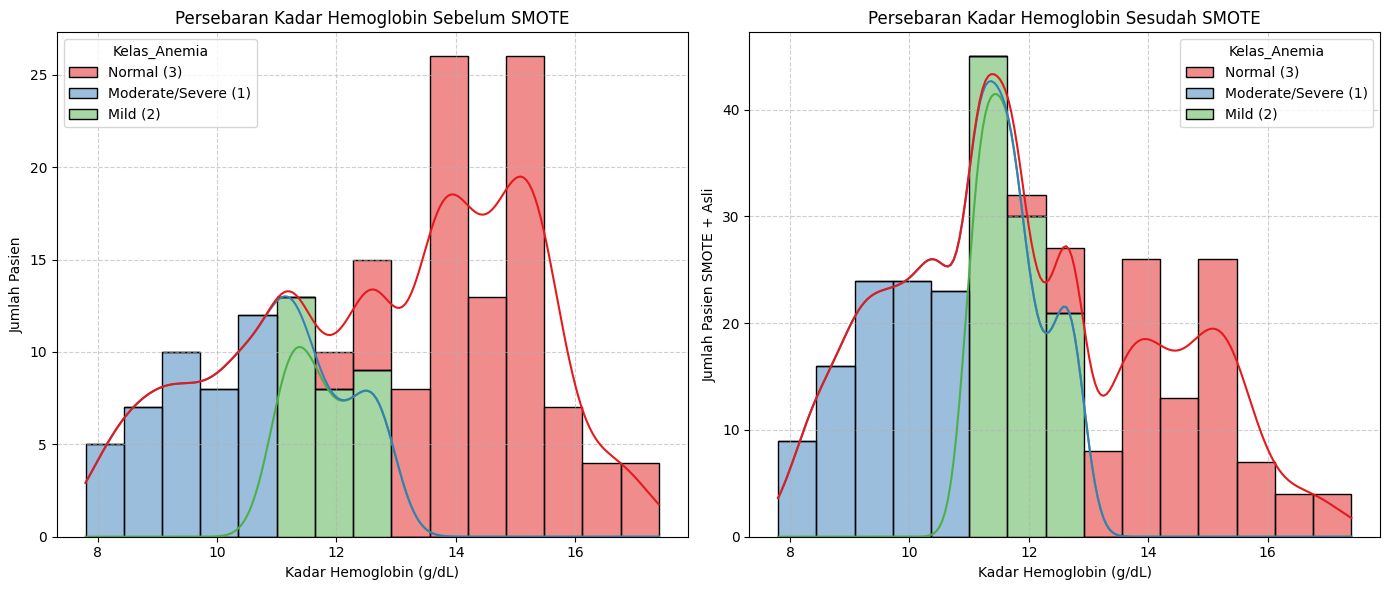

In [5]:
# --- VISUALISASI HASIL SMOTE ---

print("\nJumlah data TRAIN setelah SMOTE:")
print(y_class_resampled.value_counts())

train_data_resampled['Gender'] = train_data_resampled['Gender'].round().astype(int)
from IPython.display import display
display(train_data_resampled.head())

# 2. Visualisasi Persebaran Angka Hemoglobin (Histogram/KDE)
train_data_combined['Kelas_Anemia'] = y_class_train.map(class_names)
train_data_resampled['Kelas_Anemia'] = y_class_resampled.map(class_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafik Kiri: Sebelum SMOTE
sns.histplot(ax=axes[0], data=train_data_combined, x='Hemoglobin', hue='Kelas_Anemia', 
             palette='Set1', bins=15, kde=True, multiple="stack", edgecolor='k')
axes[0].set_title('Persebaran Kadar Hemoglobin Sebelum SMOTE')
axes[0].set_xlabel('Kadar Hemoglobin (g/dL)')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Grafik Kanan: Sesudah SMOTE
sns.histplot(ax=axes[1], data=train_data_resampled, x='Hemoglobin', hue='Kelas_Anemia', 
             palette='Set1', bins=15, kde=True, multiple="stack", edgecolor='k')
axes[1].set_title('Persebaran Kadar Hemoglobin Sesudah SMOTE')
axes[1].set_xlabel('Kadar Hemoglobin (g/dL)')
axes[1].set_ylabel('Jumlah Pasien SMOTE + Asli')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

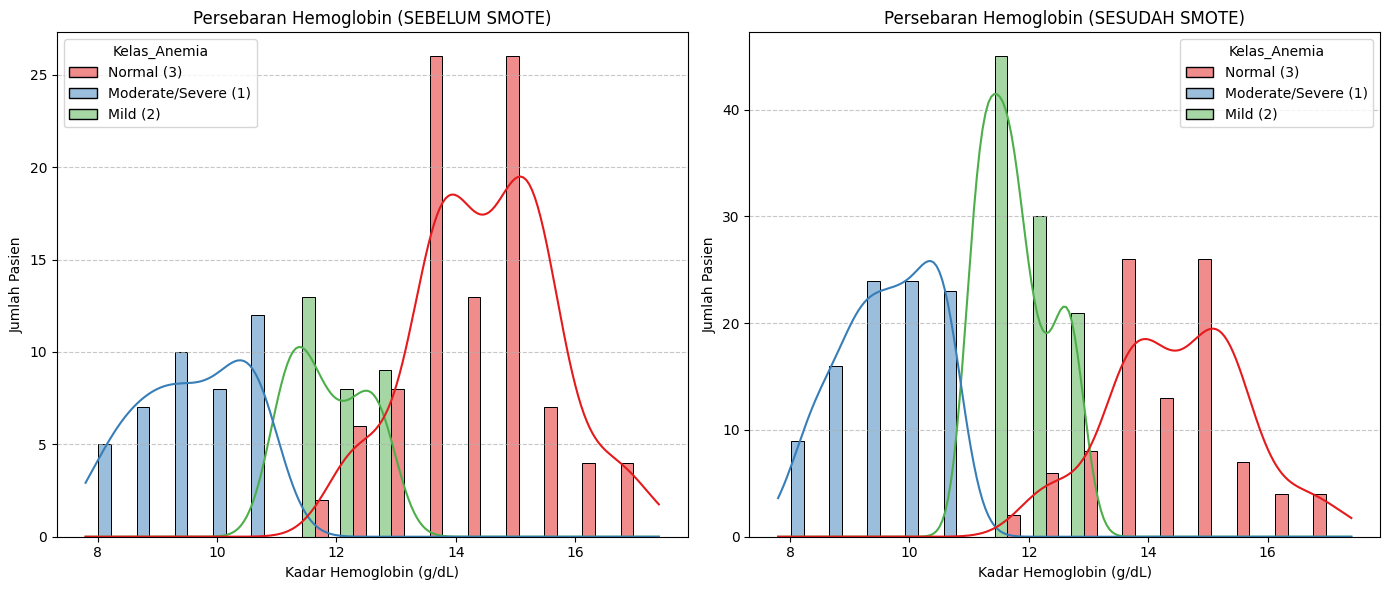

In [6]:
'''fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Grafik Kiri: Menghitung jumlah pasien tiap kelas SEBELUM SMOTE
sns.countplot(ax=axes[0], data=train_data_combined, x='Kelas_Anemia', 
              palette='Set1', edgecolor='black')
axes[0].set_title('Jumlah Pasien per Kelas (SEBELUM SMOTE)')
axes[0].set_ylabel('Total Pasien')
axes[0].set_xlabel('Kelas Anemia')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Grafik Kanan: Menghitung jumlah pasien tiap kelas SESUDAH SMOTE
sns.countplot(ax=axes[1], data=train_data_resampled, x='Kelas_Anemia', 
              palette='Set1', edgecolor='black')
axes[1].set_title('Jumlah Pasien per Kelas (SESUDAH SMOTE)')
axes[1].set_ylabel('Total Pasien')
axes[1].set_xlabel('Kelas Anemia')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()'''

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Grafik Kiri: Persebaran Hemoglobin SEBELUM SMOTE
# Menggunakan histplot dengan multiple='dodge' agar bar bersebelahan, bukan bertumpuk
sns.histplot(ax=axes[0], data=train_data_combined, x='Hemoglobin', hue='Kelas_Anemia', 
             palette='Set1', bins=15, multiple='dodge', edgecolor='black', kde=True)
axes[0].set_title('Persebaran Hemoglobin (SEBELUM SMOTE)')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].set_xlabel('Kadar Hemoglobin (g/dL)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Grafik Kanan: Persebaran Hemoglobin SESUDAH SMOTE
sns.histplot(ax=axes[1], data=train_data_resampled, x='Hemoglobin', hue='Kelas_Anemia', 
             palette='Set1', bins=15, multiple='dodge', edgecolor='black', kde=True)
axes[1].set_title('Persebaran Hemoglobin (SESUDAH SMOTE)')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].set_xlabel('Kadar Hemoglobin (g/dL)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Menghapus kolom sementara agar aman untuk proses training selanjutnya
train_data_combined.drop(columns=['Kelas_Anemia'], inplace=True)
train_data_resampled.drop(columns=['Kelas_Anemia'], inplace=True)

In [10]:
# =====================================================================
# 4. PELATIHAN MODEL (MENGGUNAKAN DATA BALANCED)
# =====================================================================

model_params = {
    'MLR': {}, 
    'SVR': {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
    'Random Forest': {'max_depth': 4, 'n_estimators': 20, 'random_state': 42},
    'Gradient Boosting': {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 20, 'random_state': 42}
}

models = {
    'MLR': make_pipeline(StandardScaler(), LinearRegression(**model_params['MLR'])),
    'SVR': make_pipeline(StandardScaler(), SVR(**model_params['SVR'])),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(**model_params['Random Forest'])),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingRegressor(**model_params['Gradient Boosting']))
}

results = {}
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train_balanced, y_hb_train_balanced)
    
    y_pred = model.predict(X_test)
    predictions_dict[name] = y_pred
    
    mse = mean_squared_error(y_hb_test, y_pred)
    mae = mean_absolute_error(y_hb_test, y_pred)
    r2 = r2_score(y_hb_test, y_pred)
    
    results[name] = {'MSE': mse, 'MAE (Error g/dL)': mae, 'R2 Score': r2}

results_df = pd.DataFrame(results).T
from IPython.display import display
print("\n=== HASIL EVALUASI MODEL ===")
display(results_df.sort_values(by='MAE (Error g/dL)'))


=== HASIL EVALUASI MODEL ===


,MSE,MAE (Error g/dL),R2 Score
Random Forest,3.999659,1.464561,0.310505
Gradient Boosting,4.122110,1.484072,0.289396
SVR,4.488219,1.502355,0.226283
MLR,4.579109,1.645288,0.210615


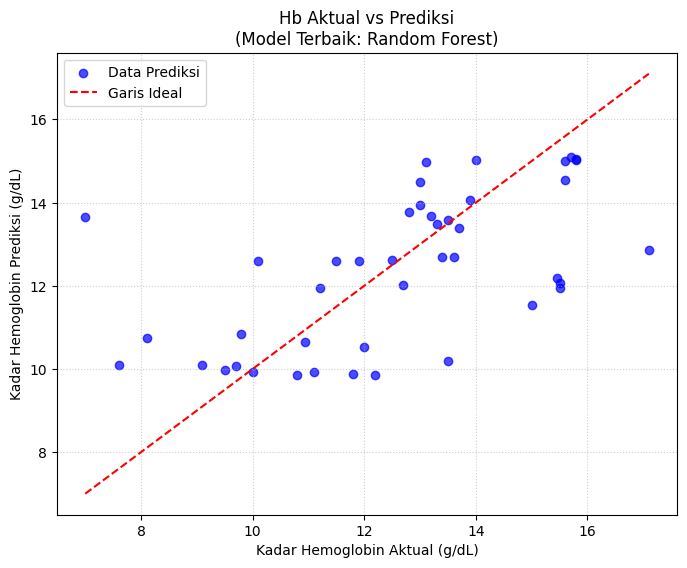

In [27]:
#cell buat visualisasi
best_model_name = results_df['MAE (Error g/dL)'].idxmin()
best_y_pred = predictions_dict[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_hb_test, best_y_pred, alpha=0.7, color='blue', label='Data Prediksi')

min_val = min(min(y_hb_test), min(best_y_pred))
max_val = max(max(y_hb_test), max(best_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')

plt.title(f'Hb Aktual vs Prediksi\n(Model Terbaik: {best_model_name})')
plt.xlabel('Kadar Hemoglobin Aktual (g/dL)')
plt.ylabel('Kadar Hemoglobin Prediksi (g/dL)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

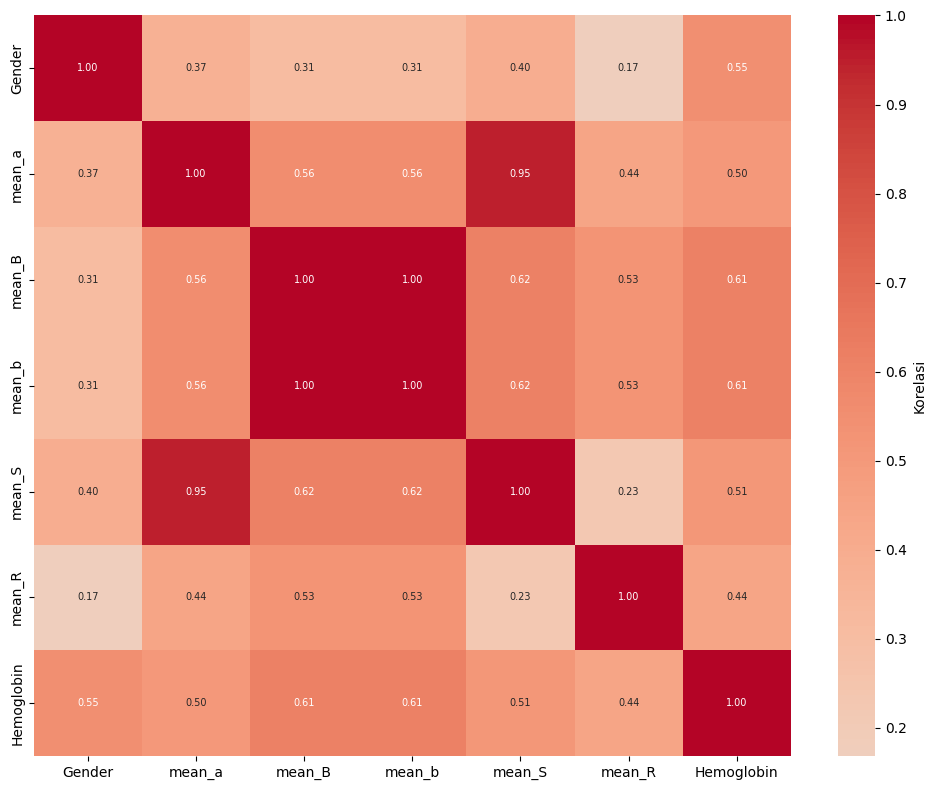

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

#Pearson Correlation Coefficient (PCC)
plt.figure(figsize=(10, 8))
#correlation_matrix = df[feature_columns + ['Hemoglobin']].corr(method='pearson')

correlation_matrix = df[selected_features + ['Hemoglobin']].corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Korelasi'}, annot_kws={'fontsize': 7})

#ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()